In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
text = """Sample text in English is utilized in a variety of fields, helping to streamline processes, ensure readability, and provide a visual idea of how the final content will appear. Below are some key areas where it’s commonly used:

1. Design and Layout Testing

Graphic designers and publishers often use sample text to test layouts and ensure that the design works well with the content. Whether it’s a website, brochure, or book, sample text helps in assessing how readable the content will be once the final text is added.

2. Web Development

In web development, developers use sample text to see how text blocks will look within the layout. This is particularly useful when creating templates, ensuring the design is responsive and readable across various screen sizes.

3. Content Creation and Proofreading

For content creators, sample text can serve as a tool for practicing language skills or testing the flow of writing. Similarly, proofreaders may use it to practice checking for grammatical errors or formatting consistency.

4. Software Development

Sample text in English is also used in software development for testing user interfaces. For example, when developing text-editing software or word processors, placeholder text helps in ensuring that the software correctly handles formatting, text wrapping, and more."""

In [3]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

Text(0.5, 1.0, 'Wordcloud')

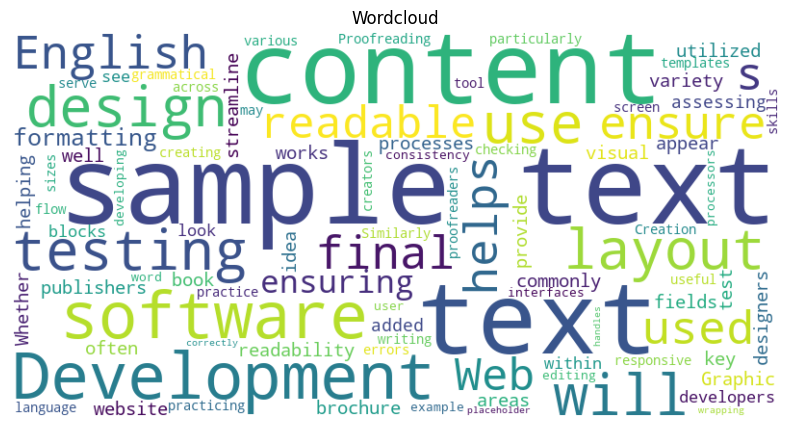

In [4]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud")

# Customizing the Word Cloud

We can customize the word cloud with different options like:

1. Maximum number of words

2. Color scheme

3. Shape of the cloud

max_words: Limits the number of words
colormap: Changes the color of the word cloud

Text(0.5, 1.0, 'Customized Word Cloud')

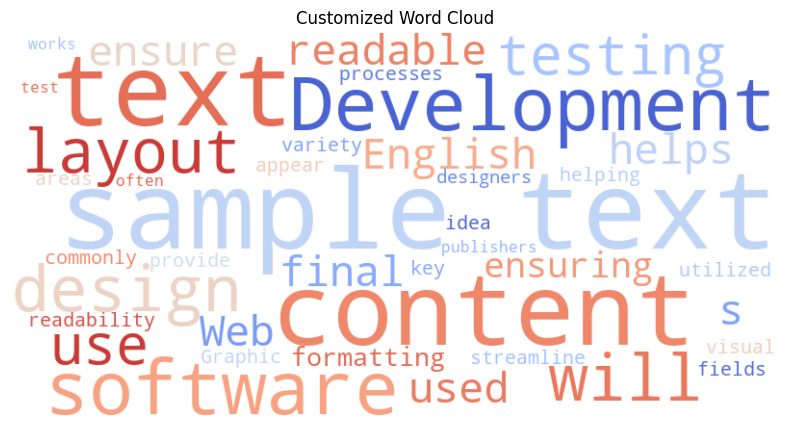

In [8]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=40, colormap='coolwarm').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Customized Word Cloud")

Before I grouped the attraction texts, I did a little cleaning by lowercasing, removing basic stop words (i.e. “a”, “the”, “is”, etc), and lemmatizing.

In [18]:
text = """
Scrum is an Agile framework that structures work into time-boxed sprints, with defined roles, artifacts, and ceremonies for iterative delivery.
Key roles include product owner, Scrum master, and development team, all collaborating to achieve sprint goals.
Scrum emphasizes transparency, inspection, and adaptation, enabling teams to respond to change and deliver value incrementally.
Start by organizing your team’s work into sprints and adopting Scrum ceremonies to improve focus and project delivery cadence.
"""

In [20]:
import nltk
from nltk import WordNetLemmatizer, word_tokenize

nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\zola\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\zola\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [21]:
lemmatizer = WordNetLemmatizer()
tokens = word_tokenize(text)
lemmatized_words = [lemmatizer.lemmatize(word) for word in tokens]
print(f"Original Text: {text}")
print(f"Lemmatized Words: {lemmatized_words}")

Original Text: 
Scrum is an Agile framework that structures work into time-boxed sprints, with defined roles, artifacts, and ceremonies for iterative delivery.
Key roles include product owner, Scrum master, and development team, all collaborating to achieve sprint goals.
Scrum emphasizes transparency, inspection, and adaptation, enabling teams to respond to change and deliver value incrementally.
Start by organizing your team’s work into sprints and adopting Scrum ceremonies to improve focus and project delivery cadence.

Lemmatized Words: ['Scrum', 'is', 'an', 'Agile', 'framework', 'that', 'structure', 'work', 'into', 'time-boxed', 'sprint', ',', 'with', 'defined', 'role', ',', 'artifact', ',', 'and', 'ceremony', 'for', 'iterative', 'delivery', '.', 'Key', 'role', 'include', 'product', 'owner', ',', 'Scrum', 'master', ',', 'and', 'development', 'team', ',', 'all', 'collaborating', 'to', 'achieve', 'sprint', 'goal', '.', 'Scrum', 'emphasizes', 'transparency', ',', 'inspection', ',', 'a

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

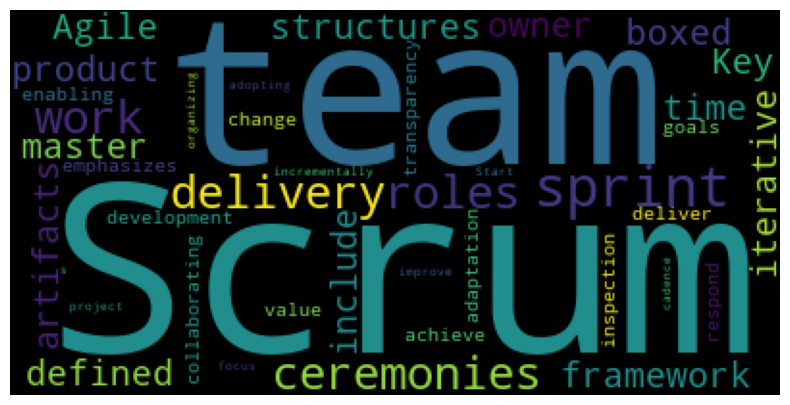

In [26]:
wc = WordCloud().generate_from_text(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')

In [27]:
#Define a list of stop words - We can tell our word cloud a custom stop words list to get rid of these.
stopwords = ['team', 'framework', 'defined']

#A function to generate the word cloud from text
def generate_basic_wordcloud(data, title):
    cloud = WordCloud(width=400,
                      height=330,
                      max_words=150,
                      colormap='tab20c',
                      stopwords=stopwords,
                      collocations=True).generate_from_text(data)
    plt.figure(figsize=(10,8))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title(title, fontsize=13)

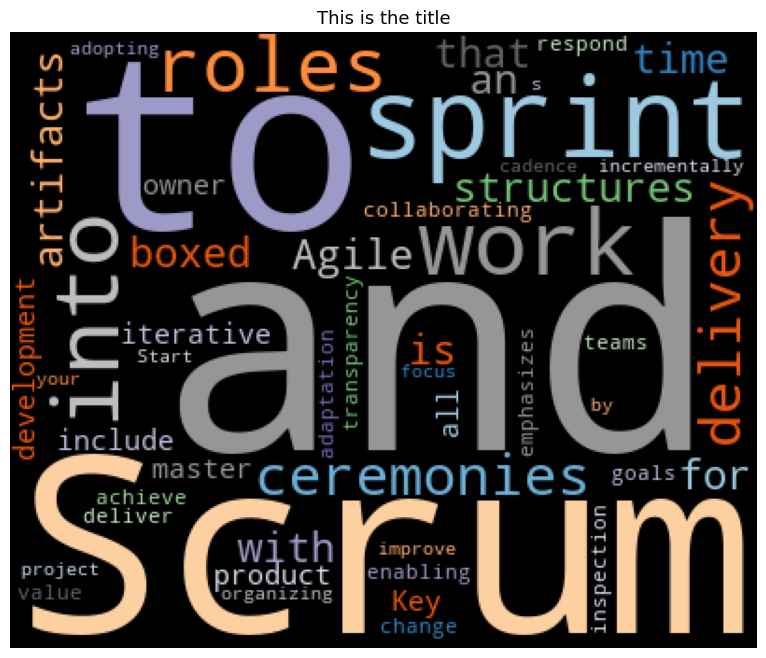

In [28]:
generate_basic_wordcloud(text, 'This is the title')

In [29]:
# A similar function, but using the mask
def generate_better_wordcloud(data, title, mask=None):
    cloud = WordCloud(scale=3,
                      max_words=150,
                      colormap='RdYlGn',
                      mask=mask,
                      background_color='white',
                      stopwords=stopwords,
                      collocations=True).generate_from_text(data)
    plt.figure(figsize=(10,8))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title(title)
    plt.show()

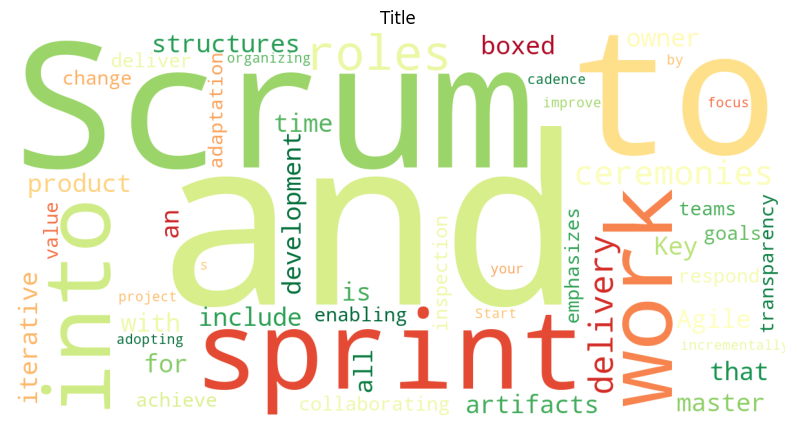

In [30]:
hungary_mask = None

generate_better_wordcloud(text, 'Title', mask=hungary_mask)

The trickiest part of using a mask is that the image you choose must have the following requirements:

a white background (it must be #ffffff, not off-white or transparent)
a definitive shape that is NOT white

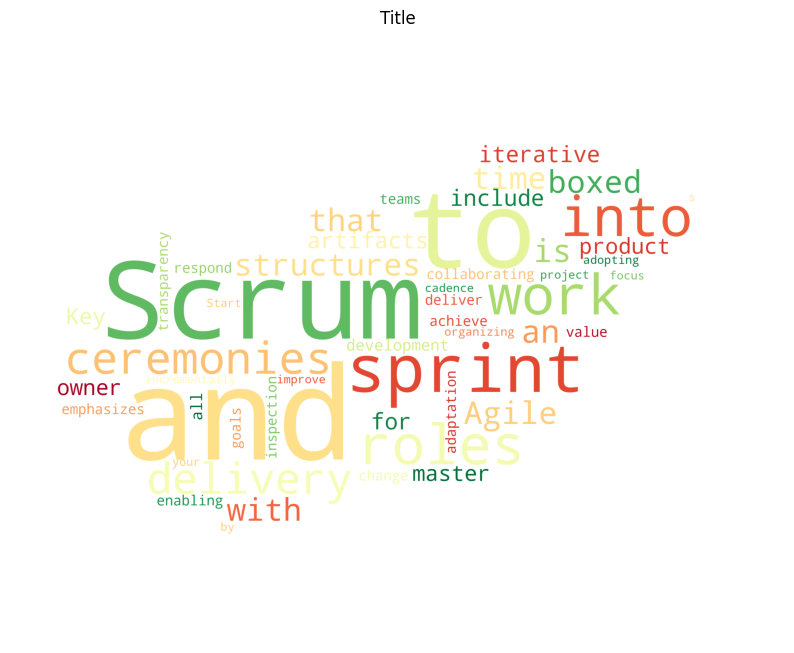

In [31]:
from PIL import Image
import numpy as np

image = Image.open('hungary_mask.png')
hungary_mask = np.array(image)

generate_better_wordcloud(text, 'Title', mask=hungary_mask)

In [32]:
from matplotlib import colormaps
list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

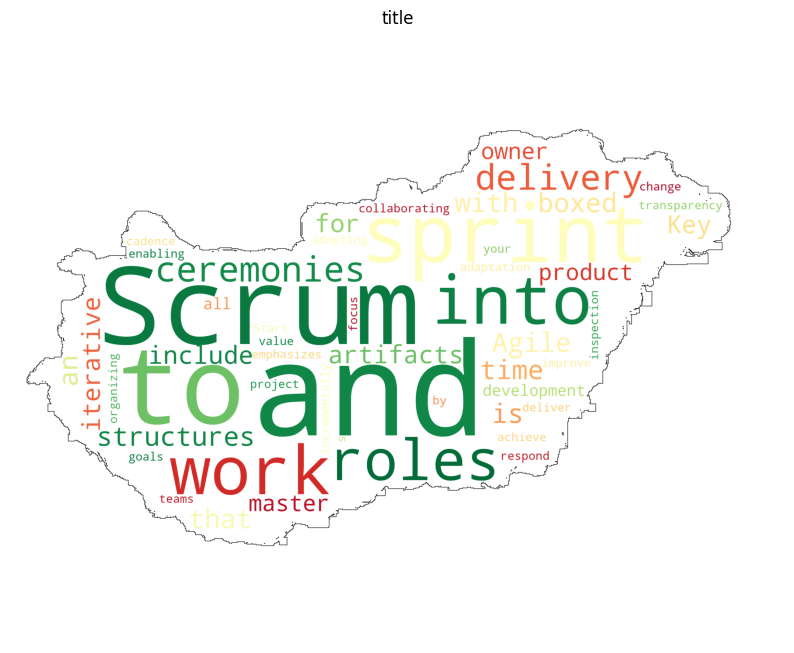

In [33]:
# Function to generate word cloud with basic contour
def generate_better_wordcloud(data, title, mask=None):
    cloud = WordCloud(scale=3,
                      max_words=150,
                      colormap='RdYlGn',
                      mask=mask,
                      background_color='white',
                      stopwords=stopwords,
                      collocations=True,
                      contour_color='black',
                      contour_width=1).generate_from_text(data)
    plt.figure(figsize=(10,8))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title(title)
    plt.show()

# Use function to generate wordcloud
generate_better_wordcloud(text, 'title', mask=hungary_mask)
